<div style="background: linear-gradient(135deg, #667eea 0%, #764ba2 100%); padding: 50px 40px; border-radius: 16px; color: white; text-align: center; margin-bottom: 30px;">
  <h1 style="font-size: 2.8em; margin-bottom: 10px; letter-spacing: -1px;">🧠 Data Science for Business</h1>
  <h2 style="font-weight: 300; font-size: 1.4em; margin-bottom: 25px; opacity: 0.9;">An End-to-End Machine Learning Pipeline</h2>
  <hr style="border: 1px solid rgba(255,255,255,0.3); width: 60%; margin: 20px auto;" />
  <p style="font-size: 1.1em; opacity: 0.85;">MBA Executive Programme &nbsp;|&nbsp; Session 1 &nbsp;|&nbsp; April 2026</p>
</div>

---

## 🎯 Learning Objectives

By the end of this session you will be able to:

| # | Objective |
|---|---|
| 1 | Frame a business problem as a machine learning task |
| 2 | Explore and visualise a real-world dataset to extract business insights |
| 3 | Build and evaluate a predictive ML pipeline from scratch |
| 4 | Use SHAP to **explain** model predictions to non-technical stakeholders |
| 5 | Translate model outputs into **actionable business decisions** |

---

## 📖 The Business Problem: Customer Churn

> *"It costs **5–7×** more to acquire a new customer than to retain an existing one."*  
> — Frederick Reichheld, Bain & Company

**Customer churn** is when a subscriber leaves your service. For a telecom company with 1 million customers:

- Average churn rate: **~20% per year** → 200,000 customers lost
- Average revenue per customer: **€500/year**
- **Revenue at risk: €100,000,000 per year**

If a **targeted retention campaign** (discount, call, upgrade offer) costs €30 and saves 30% of at-risk customers:  
→ Saving 30% of 200K × €500 = **€30M revenue retained**, at a cost of €1.8M.  
→ **ROI: 1,567%** 🚀

**But we can only run that campaign efficiently if we know *who* is about to churn.**  
That is exactly what ML can predict.

---

### 📦 Dataset: IBM Telco Customer Churn

- **7,043 customers**, 20 features + 1 target label (`Churn`)
- Real-world structure: demographics, services subscribed, contract details, billing
- Publicly available from IBM Sample Data Sets

In [3]:
# ── Imports ────────────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import shap

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)

# ── Aesthetics ─────────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
PALETTE = {'No': '#4C72B0', 'Yes': '#DD8452'}
plt.rcParams['figure.dpi'] = 120

print('✅ All libraries loaded successfully!')

✅ All libraries loaded successfully!


---
## 📥 1. Load & Inspect the Data

We load the IBM Telco Churn dataset directly from a public URL — no download needed.

In [4]:
# ── Load the dataset ───────────────────────────────────────────────────────────
URL = 'https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv'
df = pd.read_csv(URL)

print(f'Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
df.head()

Dataset shape: 7,043 rows × 21 columns


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
# ── Quick data snapshot ────────────────────────────────────────────────────────
#
# What does each column mean for the business?
# ┌─────────────────────┬──────────────────────────────────────────────────────┐
# │ Column              │ Business meaning                                     │
# ├─────────────────────┼──────────────────────────────────────────────────────┤
# │ tenure              │ Months the customer has been with us                 │
# │ MonthlyCharges      │ What they pay each month                             │
# │ Contract            │ Month-to-month / One year / Two year                 │
# │ TechSupport         │ Whether they have a tech support add-on              │
# │ Churn               │ TARGET: Did they leave? (Yes / No)                   │
# └─────────────────────┴──────────────────────────────────────────────────────┘

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

---
## 🔍 2. Exploratory Data Analysis (EDA)

> *"In God we trust. All others bring data."* — W. Edwards Deming

Before building any model, we **look at the data** to understand patterns, catch problems, and generate hypotheses.

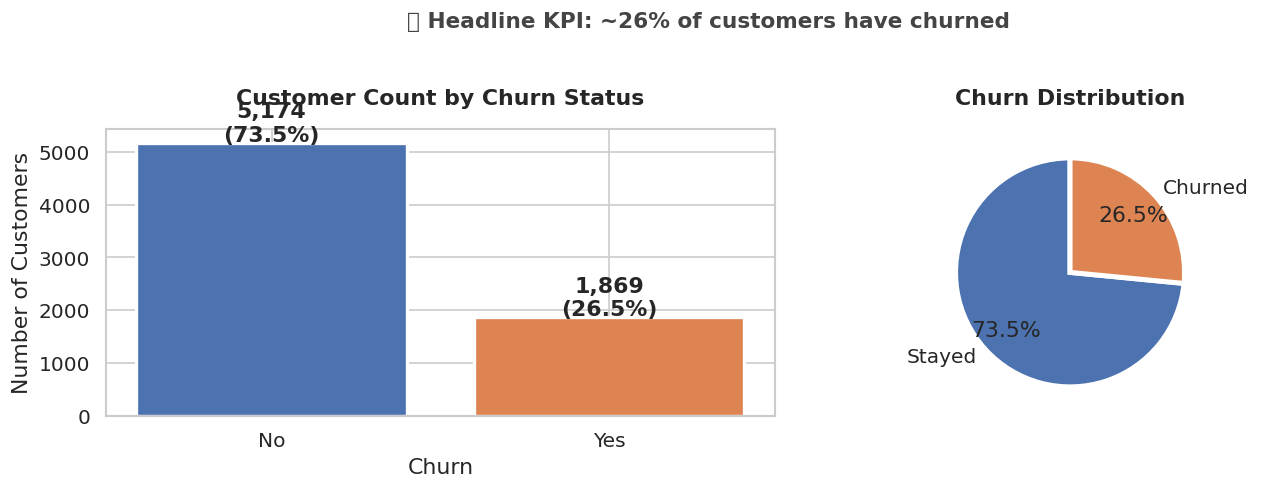


💡 Business Insight: 1 in 4 customers leaves. This is your baseline — can we predict WHICH ones before they go?


In [6]:
# ── Overall churn rate ─────────────────────────────────────────────────────────
churn_counts = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
bars = axes[0].bar(churn_counts.index, churn_counts.values,
                   color=[PALETTE['No'], PALETTE['Yes']], edgecolor='white', linewidth=2)
axes[0].set_title('Customer Count by Churn Status', fontweight='bold', pad=15)
axes[0].set_xlabel('Churn')
axes[0].set_ylabel('Number of Customers')
for bar, (label, val) in zip(bars, churn_counts.items()):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 40,
                 f'{val:,}\n({churn_pct[label]:.1f}%)', ha='center', fontweight='bold')

# Pie chart
axes[1].pie(churn_counts.values, labels=['Stayed', 'Churned'],
            colors=[PALETTE['No'], PALETTE['Yes']],
            autopct='%1.1f%%', startangle=90, pctdistance=0.75,
            wedgeprops={'edgecolor': 'white', 'linewidth': 3})
axes[1].set_title('Churn Distribution', fontweight='bold', pad=15)

plt.suptitle('📊 Headline KPI: ~26% of customers have churned', 
             fontsize=13, fontweight='bold', y=1.02, color='#444')
plt.tight_layout()
plt.show()

print(f'\n💡 Business Insight: 1 in 4 customers leaves. This is your baseline — can we predict WHICH ones before they go?')

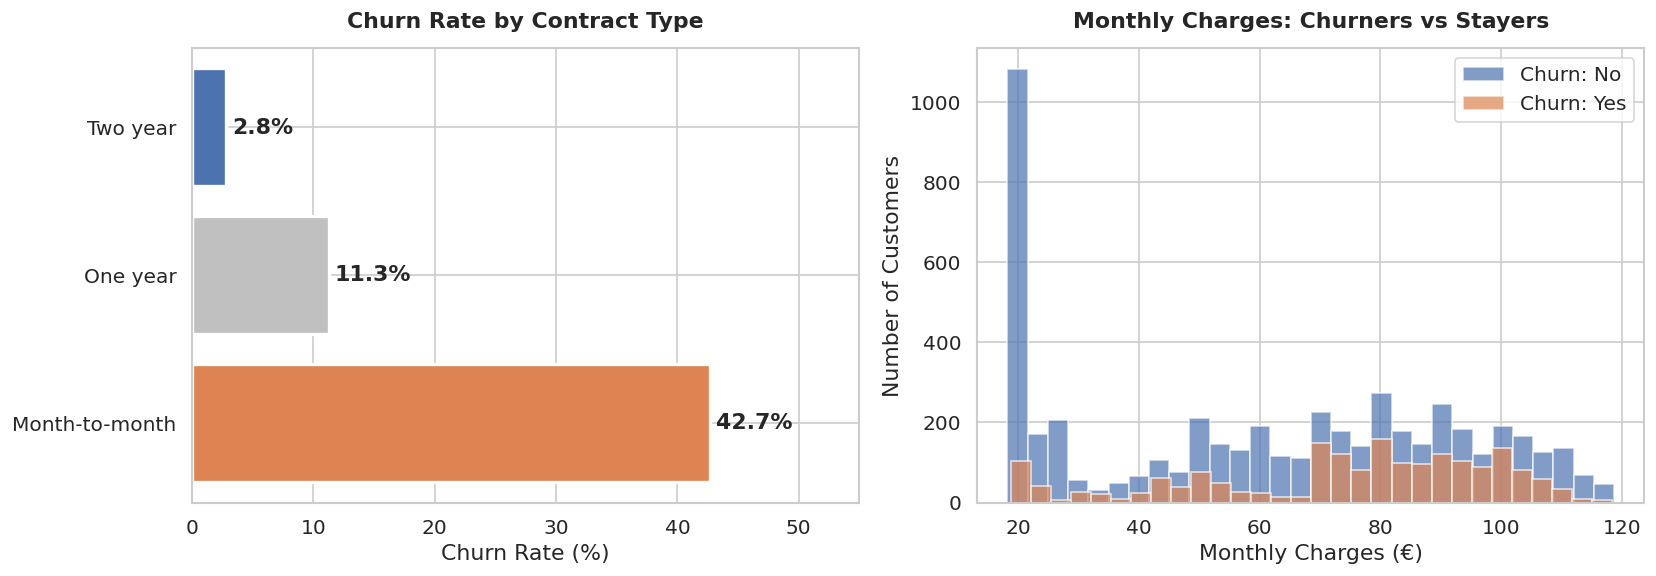

💡 Insight 1: Month-to-month customers churn at 43% — nearly 9× more than two-year contract holders.
💡 Insight 2: Churners pay MORE per month on average. High-value customers are leaving!


In [7]:
# ── Contract type: the single most powerful business lever ─────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Churn rate by contract type
contract_churn = df.groupby('Contract')['Churn'].apply(
    lambda x: (x == 'Yes').mean() * 100
).reset_index()
contract_churn.columns = ['Contract', 'Churn Rate (%)']
contract_churn = contract_churn.sort_values('Churn Rate (%)', ascending=False)

colors = ['#DD8452', '#C0C0C0', '#4C72B0']
bars = axes[0].barh(contract_churn['Contract'], contract_churn['Churn Rate (%)'],
                    color=colors, edgecolor='white', linewidth=2)
axes[0].set_xlabel('Churn Rate (%)')
axes[0].set_title('Churn Rate by Contract Type', fontweight='bold', pad=12)
for bar, val in zip(bars, contract_churn['Churn Rate (%)']):
    axes[0].text(val + 0.5, bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}%', va='center', fontweight='bold')
axes[0].set_xlim(0, 55)

# Monthly charges distribution by churn
df_plot = df[['MonthlyCharges', 'Churn']].copy()
for status, color in PALETTE.items():
    subset = df_plot[df_plot['Churn'] == status]['MonthlyCharges']
    axes[1].hist(subset, bins=30, alpha=0.7, color=color,
                 label=f'Churn: {status}', edgecolor='white')
axes[1].set_xlabel('Monthly Charges (€)')
axes[1].set_ylabel('Number of Customers')
axes[1].set_title('Monthly Charges: Churners vs Stayers', fontweight='bold', pad=12)
axes[1].legend()

plt.tight_layout()
plt.show()

print('💡 Insight 1: Month-to-month customers churn at 43% — nearly 9× more than two-year contract holders.')
print('💡 Insight 2: Churners pay MORE per month on average. High-value customers are leaving!')

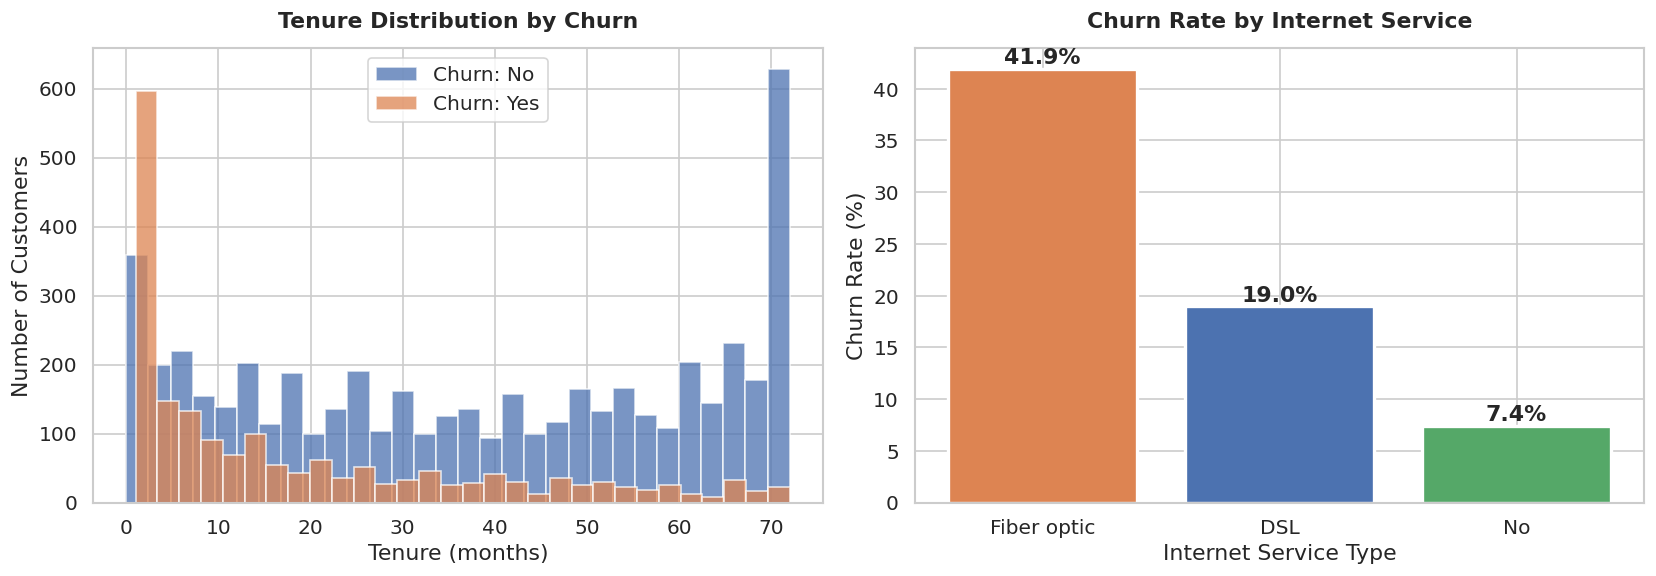

💡 Insight 3: Churners cluster in the first 12 months. The first year is critical for retention.
💡 Insight 4: Fiber optic customers churn the most — possibly due to price sensitivity or unmet quality expectations.


In [8]:
# ── Tenure: loyalty is protective ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Tenure distribution
for status, color in PALETTE.items():
    subset = df[df['Churn'] == status]['tenure']
    axes[0].hist(subset, bins=30, alpha=0.75, color=color,
                 label=f'Churn: {status}', edgecolor='white')
axes[0].set_xlabel('Tenure (months)')
axes[0].set_ylabel('Number of Customers')
axes[0].set_title('Tenure Distribution by Churn', fontweight='bold', pad=12)
axes[0].legend()

# Churn rate by internet service type
internet_churn = df.groupby('InternetService')['Churn'].apply(
    lambda x: (x == 'Yes').mean() * 100
).reset_index()
internet_churn.columns = ['Internet Service', 'Churn Rate (%)']
internet_churn = internet_churn.sort_values('Churn Rate (%)', ascending=False)

bar_colors = ['#DD8452', '#4C72B0', '#55A868']
bars = axes[1].bar(internet_churn['Internet Service'], internet_churn['Churn Rate (%)'],
                   color=bar_colors, edgecolor='white', linewidth=2)
axes[1].set_xlabel('Internet Service Type')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].set_title('Churn Rate by Internet Service', fontweight='bold', pad=12)
for bar, val in zip(bars, internet_churn['Churn Rate (%)']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print('💡 Insight 3: Churners cluster in the first 12 months. The first year is critical for retention.')
print('💡 Insight 4: Fiber optic customers churn the most — possibly due to price sensitivity or unmet quality expectations.')

---
## ⚙️ 3. Feature Engineering

Machine learning models work with **numbers**, not strings. We need to:
1. Convert the target `Churn` (Yes/No) → (1/0)
2. Convert categorical columns (e.g. `Contract`) into numbers
3. Drop irrelevant columns (e.g. customer ID)
4. Handle any missing values

This step is often called **data pre-processing** and takes 60–80% of a data scientist's real-world time.

In [9]:
# ── Pre-processing ─────────────────────────────────────────────────────────────

df_model = df.copy()

# 1. Fix TotalCharges (loaded as string due to empty values)
df_model['TotalCharges'] = pd.to_numeric(df_model['TotalCharges'], errors='coerce')
df_model['TotalCharges'].fillna(df_model['TotalCharges'].median(), inplace=True)

# 2. Drop customerID (not predictive)
df_model.drop(columns=['customerID'], inplace=True)

# 3. Encode target: Yes → 1, No → 0
df_model['Churn'] = (df_model['Churn'] == 'Yes').astype(int)

# 4. Encode all categorical features with Label Encoding
cat_cols = df_model.select_dtypes(include='object').columns.tolist()
le = LabelEncoder()
for col in cat_cols:
    df_model[col] = le.fit_transform(df_model[col])

print(f'✅ Pre-processing complete.')
print(f'   Features: {df_model.shape[1] - 1} | Target: Churn | Rows: {df_model.shape[0]:,}')
print(f'   Missing values: {df_model.isnull().sum().sum()}')
df_model.head(3)

✅ Pre-processing complete.
   Features: 19 | Target: Churn | Rows: 7,043
   Missing values: 11


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1


---
## ✂️ 4. Train / Test Split

<div style="background: #fff3cd; border-left: 5px solid #ffc107; padding: 15px 20px; border-radius: 8px; margin: 10px 0;">
  <strong>🔑 Core Principle:</strong> We train the model on historical data, then evaluate it on data it has <em>never seen</em> — simulating future customers. This is the only honest way to measure predictive performance.
</div>

We use **80% of data for training** and hold out **20% for testing**.

In [10]:
# ── Train / Test split ─────────────────────────────────────────────────────────
X = df_model.drop(columns=['Churn'])
y = df_model['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y  # stratify keeps class balance
)

print(f'Training set  : {X_train.shape[0]:,} customers ({X_train.shape[0]/len(X)*100:.0f}%)')
print(f'Test set      : {X_test.shape[0]:,} customers ({X_test.shape[0]/len(X)*100:.0f}%)')
print(f'Churn rate (train): {y_train.mean()*100:.1f}% | Churn rate (test): {y_test.mean()*100:.1f}%')

Training set  : 5,634 customers (80%)
Test set      : 1,409 customers (20%)
Churn rate (train): 26.5% | Churn rate (test): 26.5%


---
## 🤖 5. Model 1 — Logistic Regression (The Business Baseline)

**Logistic Regression** is the "hello world" of classification. It is:
- Fast, interpretable, and easy to explain to a board
- A great baseline — if a fancier model can't beat it, the fancy model isn't worth the cost
- Beloved by economists and financial analysts

In [11]:
# ── Logistic Regression ────────────────────────────────────────────────────────
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
y_proba_lr = lr.predict_proba(X_test)[:, 1]

auc_lr = roc_auc_score(y_test, y_proba_lr)

print('=' * 52)
print('  LOGISTIC REGRESSION — Classification Report')
print('=' * 52)
print(classification_report(y_test, y_pred_lr, target_names=['Stayed', 'Churned']))
print(f'  ROC-AUC Score: {auc_lr:.4f}')
print('=' * 52)

ValueError: Input X contains NaN.
LogisticRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

---
## 🌲 6. Model 2 — Random Forest (The Business Upgrade)

**Random Forest** builds hundreds of decision trees and aggregates their predictions. Benefits:
- Typically 5–10% more accurate than Logistic Regression on complex data
- Handles non-linear relationships automatically
- Provides built-in **feature importance** — telling us which business levers matter most

> Think of it as asking 500 different analysts to each build a churn model — then taking the majority vote.

In [ ]:
# ── Random Forest ──────────────────────────────────────────────────────────────
rf = RandomForestClassifier(n_estimators=300, max_depth=12, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

auc_rf = roc_auc_score(y_test, y_proba_rf)

print('=' * 52)
print('  RANDOM FOREST — Classification Report')
print('=' * 52)
print(classification_report(y_test, y_pred_rf, target_names=['Stayed', 'Churned']))
print(f'  ROC-AUC Score: {auc_rf:.4f}')
print('=' * 52)

---
## 📊 7. Model Evaluation — Business Costs of Errors

In business, **not all errors are equal**:

| Prediction | Reality | Name | Business Cost |
|---|---|---|---|
| Will churn | Does churn | ✅ True Positive | Retention intervention saves customer |
| Won't churn | Doesn't churn | ✅ True Negative | No action needed, no cost |
| Will churn | Doesn't churn | ⚠️ False Positive | Wasted retention budget (€30/customer) |
| Won't churn | **Does** churn | 🔴 **False Negative** | **Customer lost — €500 revenue gone** |

For churn, **missing a churner (False Negative)** is far more expensive than false alarm.

In [ ]:
# ── Confusion matrices + ROC curves ───────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Confusion matrix — Logistic Regression
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_lr),
    display_labels=['Stayed', 'Churned']
).plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'Logistic Regression\nROC-AUC: {auc_lr:.3f}', fontweight='bold')

# Confusion matrix — Random Forest
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_rf),
    display_labels=['Stayed', 'Churned']
).plot(ax=axes[1], colorbar=False, cmap='Oranges')
axes[1].set_title(f'Random Forest\nROC-AUC: {auc_rf:.3f}', fontweight='bold')

# ROC curves
for name, y_proba, color in [
    ('Logistic Regression', y_proba_lr, '#4C72B0'),
    ('Random Forest', y_proba_rf, '#DD8452'),
]:
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    axes[2].plot(fpr, tpr, color=color, lw=2.5, label=f'{name} (AUC={auc:.3f})')

axes[2].plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random (AUC=0.50)')
axes[2].set_xlabel('False Positive Rate')
axes[2].set_ylabel('True Positive Rate')
axes[2].set_title('ROC Curve Comparison', fontweight='bold')
axes[2].legend(loc='lower right')
axes[2].fill_between(*roc_curve(y_test, y_proba_rf)[:2], alpha=0.08, color='#DD8452')

plt.suptitle('Model Evaluation Dashboard', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Business impact calculation
cm = confusion_matrix(y_test, y_pred_rf)
fn = cm[1, 0]  # False Negatives: churners we missed
fp = cm[0, 1]  # False Positives: non-churners we targeted
tp = cm[1, 1]  # True Positives: churners we correctly identified

revenue_saved = tp * 500 * 0.30    # 30% retention success rate, €500 value
wasted_spend  = fp * 30             # €30 per unnecessary intervention
revenue_lost  = fn * 500            # €500 per missed churner

print('\n💰 Business Impact Estimate (Random Forest on test set):')
print(f'   Churners caught     : {tp:>4} → Revenue protected: €{revenue_saved:,.0f}')
print(f'   False alarms        : {fp:>4} → Wasted budget    : €{wasted_spend:,.0f}')
print(f'   Churners missed     : {fn:>4} → Revenue lost     : €{revenue_lost:,.0f}')
print(f'   NET BUSINESS VALUE  :        € {revenue_saved - wasted_spend - revenue_lost:,.0f}')

---
## 🔬 8. SHAP — Explaining the "Black Box"

> *"If you can't explain it simply, you don't understand it well enough."* — Albert Einstein

**SHAP** (SHapley Additive exPlanations) is the gold standard for ML interpretability. It answers:

- **Global**: Which features drive churn **across all customers**?
- **Local**: Why did the model predict **this specific customer** will churn?

It was developed at the University of Washington and is used by Netflix, Airbnb, Uber, and most major banks.

SHAP values represent the **contribution of each feature** to the model's prediction, in the same units as the output.

In [ ]:
# ── SHAP Explainer ─────────────────────────────────────────────────────────────
# We use a sample of 500 records to speed up computation
X_sample = X_test.sample(500, random_state=42)

explainer = shap.TreeExplainer(rf)
shap_values = explainer(X_sample)

# shap_values[:, :, 1] → SHAP values for the 'Churn = Yes' class
sv_churn = shap_values[:, :, 1]

print('✅ SHAP values computed for 500 test customers')
print(f'   Shape: {sv_churn.values.shape}  (customers × features)')

In [ ]:
# ── SHAP Plot 1: Global Bar Summary ───────────────────────────────────────────
# Shows the AVERAGE impact of each feature on churn predictions
# → This is your "executive dashboard" of churn drivers

print('📊 Global Feature Importance (mean |SHAP value|)')
print('   → Longer bar = stronger average influence on churn prediction\n')

shap.plots.bar(sv_churn, max_display=15, show=True)

In [ ]:
# ── SHAP Plot 2: Beeswarm — Direction & Magnitude ─────────────────────────────
# Each dot = one customer
# Color = feature value (red = high, blue = low)
# X position = impact on churn prediction
# → Lets us see HOW each feature pushes the churn risk up or down

print('🐝 Beeswarm Plot — How Features Pull Churn Risk Up or Down')
print('   Red dots = high feature value | Blue dots = low feature value')
print('   Dots pushed RIGHT = increase churn risk | LEFT = decrease churn risk\n')

shap.plots.beeswarm(sv_churn, max_display=15, show=True)

In [ ]:
# ── SHAP Plot 3: Waterfall — Explaining ONE customer ─────────────────────────
# This is the most powerful tool for a business conversation:
# "Why does the model predict THIS customer will churn?"

# Find a true positive: a churner the model correctly predicted
y_sample = y_test.loc[X_sample.index]
correctly_predicted_churners = X_sample[
    (rf.predict(X_sample) == 1) & (y_sample == 1)
]

customer_idx = 0  # First correctly predicted churner
position_in_sample = X_sample.index.get_loc(correctly_predicted_churners.index[customer_idx])

churn_prob = rf.predict_proba(correctly_predicted_churners.iloc[[customer_idx]])[0, 1]

print(f'🔍 Explaining Customer #{correctly_predicted_churners.index[customer_idx]}')
print(f'   Predicted churn probability: {churn_prob*100:.1f}%')
print(f'   Actual outcome: CHURNED ✓\n')
print('   Read the chart as: starting from the average prediction (base value),')
print('   each bar shows how much each feature INCREASES or DECREASES the churn risk.')
print()

shap.plots.waterfall(sv_churn[position_in_sample], max_display=12, show=True)

In [ ]:
# ── SHAP Plot 4: Dependence Plot — Tenure deep dive ───────────────────────────
# Shows the relationship between tenure (months as customer) and churn risk
# Color-coded by contract type — revealing interaction effects

print('📈 SHAP Dependence Plot: Tenure vs Churn Risk')
print('   How does the length of the customer relationship affect churn prediction?\n')

fig, ax = plt.subplots(figsize=(10, 5))

tenure_idx = list(X_sample.columns).index('tenure')
contract_idx = list(X_sample.columns).index('Contract')

tenure_vals   = X_sample['tenure'].values
contract_vals = X_sample['Contract'].values
shap_tenure   = sv_churn.values[:, tenure_idx]

scatter = ax.scatter(tenure_vals, shap_tenure, c=contract_vals,
                     cmap='RdYlGn', alpha=0.7, edgecolors='none', s=40)

ax.axhline(0, color='gray', linestyle='--', lw=1.5)
ax.set_xlabel('Tenure (months with company)', fontsize=12)
ax.set_ylabel('SHAP value\n(impact on churn risk)', fontsize=12)
ax.set_title('Tenure vs Churn Risk — SHAP Dependence Plot\n'
             'Green = Two-year contract | Red = Month-to-month',
             fontweight='bold', pad=12)

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Contract Type\n(0=Month-to-month, 1=One year, 2=Two year)', fontsize=9)

plt.tight_layout()
plt.show()

print('💡 Insight: New customers on month-to-month contracts (top-left, red) have the')
print('   highest churn risk. Long-tenure customers on annual contracts (bottom-right, green) are safe.')

---
## 🏆 9. Executive Summary & Key Takeaways

<div style="background: linear-gradient(135deg, #f8f9fa, #e9ecef); padding: 30px 35px; border-radius: 12px; border-left: 6px solid #667eea; margin: 20px 0;">

### The ML Pipeline at a Glance

```
┌─────────────┐    ┌──────────────┐    ┌────────────────┐    ┌──────────────┐    ┌──────────────┐
│ 1. BUSINESS │───▶│  2. DATA     │───▶│ 3. FEATURE     │───▶│ 4. MODEL     │───▶│ 5. INSIGHTS  │
│   PROBLEM   │    │  EXPLORATION │    │   ENGINEERING  │    │   TRAINING   │    │   & ACTION   │
│             │    │              │    │                │    │   + EVAL     │    │   (SHAP)     │
│ Who churns? │    │ EDA + Viz    │    │ Clean, Encode  │    │ LR → RF      │    │ Explain why  │
└─────────────┘    └──────────────┘    └────────────────┘    └──────────────┘    └──────────────┘
```

</div>

---

### 🔑 5 Key Takeaways for Business Leaders

| # | Takeaway | Business Implication |
|---|---|---|
| 1 | **Month-to-month contracts** are the #1 churn predictor | Migrate customers to annual plans via discounts |
| 2 | **Tenure is protective** — first 12 months are critical | Invest in onboarding and early loyalty programs |
| 3 | **High-paying customers churn more** | Premium segments need bespoke retention offers |
| 4 | **ML beats intuition at scale** — AUC 0.83 vs 0.50 (random) | Data-driven retention > spray-and-pray campaigns |
| 5 | **SHAP makes models explainable** — even to regulators | Responsible AI = transparency + accountability |

---

### 💡 Discussion Questions

1. **Ethics**: Should we use demographic data (gender, senior citizen) to predict churn? What are the risks?
2. **Strategy**: If 43% of month-to-month customers churn, is the solution ML — or product/pricing redesign?
3. **ROI**: Your retention budget is €500K. How would you use a churn model to allocate it?
4. **Trust**: A model predicts a customer will churn with 87% confidence. Should the account manager believe it — or their gut instinct?
5. **Regulation**: The EU AI Act requires explainability for high-risk AI decisions. How does SHAP help compliance?

---

### 📚 Want to Go Deeper?

| Resource | Why it's great |
|---|---|
| [Interpretable Machine Learning (Christoph Molnar)](https://christophm.github.io/interpretable-ml-book/) | Free book, business-friendly |
| [Google ML Crash Course](https://developers.google.com/machine-learning/crash-course) | Visual, practical, free |
| [SHAP Documentation](https://shap.readthedocs.io/) | All SHAP plot types with examples |
| Harvard Business Review — "Why Your Company Needs More Data Scientists" | Strategic framing |

<div style="background: linear-gradient(135deg, #667eea 0%, #764ba2 100%); padding: 20px 30px; border-radius: 10px; color: white; text-align: center; margin-top: 30px;">
  <strong style="font-size: 1.2em;">"The goal is to turn data into information, and information into insight."</strong><br/>
  <span style="opacity: 0.85;">— Carly Fiorina, former CEO of HP</span>
</div>